In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path
from f_readpl4 import readpl4
from sklearn.model_selection import train_test_split
from scipy.stats import entropy, kurtosis
from scipy.fft import rfft, rfftfreq
from scipy.signal import butter, filtfilt, hilbert
import pywt
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings(action="ignore"):
    fxn()

In [10]:
def listar_arquivos_pl4(caminho_pasta: str, recursivo: bool = True) -> list[str]:
    pasta = Path(caminho_pasta)

    if not pasta.is_dir():
        raise ValueError(f"O diretório '{caminho_pasta}' não existe.")

    # rglob busca recursivamente (inclui subpastas); glob busca apenas na raiz
    padrao = "**/*.pl4" if recursivo else "*.pl4"

    return [str(arquivo.resolve()) for arquivo in pasta.glob(padrao)]

def normalize_zscore(df):
    '''
    Normalizes data using Z-score (Standardization).
    Result has Mean = 0 and Std = 1.
    '''
    return (df - df.mean()) / df.std()

def df_energy_rolling(df, w):
    '''
    Calculates energy of signals in df for each window in list "w" (rolling window).
    '''
    results = []

    for i, col in enumerate(df.columns):
        try:
            window_size = w[i]
            energy = df[col].pow(2).rolling(window=window_size, step=window_size//2).mean()
            results.append(energy)
        except (IndexError, KeyError):
            print(f"Warning: There is no window for column '{col}'.")
    
    return pd.concat(results, axis=1)

def df_crest_factor_rolling(df, w):
    '''
    Calculates Crest Factor (Peak / RMS) of signals in df for each window in list "w" (rolling window).
    '''
    results = []

    for i, col in enumerate(df.columns):
        try:
            window_size = w[i] 
            grouper = df.index // window_size
            peak_val = df[col].abs().rolling(window=window_size, step=window_size//2).max()
            rms_val = df[col].pow(2).rolling(window=window_size, step=window_size//2).mean().pow(0.5)
            crest_factor = peak_val / rms_val
            results.append(crest_factor)
            
        except (IndexError, KeyError):
            print(f"Warning: There is no window for column '{col}'.")
    
    return pd.concat(results, axis=1)

def df_bandpass_filtering(df, fs, f_center, bandwidth=10.0, order=4):
    '''
    Applies a Butterworth Bandpass filter to each column in df.
    The filter is applied to the full signal to avoid windowing artifacts.
    
    Parameters:
    - df: Input DataFrame with raw signals.
    - fs: Sampling frequency in Hz.
    - f_center: Target frequency (e.g., 60, 120, 180 Hz).
    - bandwidth: Width of the passband in Hz.
    - order: Filter order (higher means steeper roll-off).
    '''
    results = []

    for i,col in enumerate(df.columns):
        try:
            # 1. Design the filter coefficients (Nyquist requirement: $f_{nyq} = \frac{fs}{2}$)
            nyq = 0.5 * fs[i]
            low = (f_center - bandwidth / 2) / nyq
            high = (f_center + bandwidth / 2) / nyq
            
            # Constrain frequencies to valid range (0 to 1)
            if low <= 0: low = 0.001
            if high >= 1: high = 0.999

            b, a = butter(order, [low, high], btype='band')
            # 2. Extract raw values and handle NaNs
            # We drop NaNs to filter, then we will re-align if necessary.
            # For power signals, continuity is key.
            raw_data = df[col].replace([np.inf, -np.inf], np.nan).dropna().values
            
            if len(raw_data) < (order * 3):
                # filtfilt requires a minimum signal length to be stable
                filtered_series = pd.Series([np.nan] * len(df[col]), index=df.index)
            else:
                # 3. Apply Zero-Phase Filtering (filtfilt)
                # This ensures the filtered harmonic is perfectly aligned with the original wave
                y = filtfilt(b, a, raw_data)
                
                # Reconstruct as a Series to preserve index
                filtered_series = pd.Series(y, name=f"f{int(f_center)}_{col}")
            
            results.append(filtered_series)

        except Exception as e:
            print(f"Warning: Could not process column '{col}'. Error: {e}")
    
    # 4. Concatenate results into a new DataFrame
    return pd.concat(results, axis=1)

def df_envelope_rms(df):
    '''
    Calculates the RMS Amplitude using the Hilbert Transform Envelope.
    FIX: Handles variable length due to NaNs by preserving the valid index.
    
    Returns:
    - RMS value (Amplitude / sqrt(2)) aligned with original index.
    '''
    results = []

    for col in df.columns:
        try:
            # 1. Limpeza Inteligente (Guardando o Índice)
            # Removemos NaNs, mas guardamos QUEM são os dados válidos
            valid_series = df[col].replace([np.inf, -np.inf], np.nan).dropna()
            
            raw_data = valid_series.values
            valid_index = valid_series.index  # <--- A CHAVE DO PROBLEMA
            
            if len(raw_data) == 0:
                # Se a coluna for toda vazia, retorna série de NaNs do tamanho original
                rms_series = pd.Series(np.nan, index=df.index, name=f"rms_{col}")
            else:
                # 2. Envelope Analítico (Hilbert)
                analytic_signal = hilbert(raw_data)
                amplitude_envelope = np.abs(analytic_signal)
                
                # 3. Conversão para RMS (Pico / sqrt(2))
                rms_values = amplitude_envelope / np.sqrt(2)
                
                # 4. Reconstrução usando o ÍNDICE VÁLIDO
                # Agora o tamanho de rms_values bate com valid_index
                rms_series = pd.Series(rms_values, name=f"rms_{col}", index=valid_index)
                
                # 5. Reindexação final
                # Expande de volta para o tamanho total (94452), colocando NaNs onde não calculamos
                rms_series = rms_series.reindex(df.index)
            
            results.append(rms_series)

        except Exception as e:
            print(f"Error calculating Envelope RMS for '{col}': {e}")
            # Em caso de erro fatal, garante que o código não pare, retornando vazio
            results.append(pd.Series(np.nan, index=df.index, name=f"rms_{col}"))
            
    return pd.concat(results, axis=1)

def df_temporal_derivative_simple(df, t):
    '''
    Calculates the Temporal Derivative using Backward Difference (Simple Difference).
    Equation: dx/dt = (x[t] - x[t-1]) / (1/t)

    Parameters:
    - t: Window size in samples, ususally (sample rate/fundamental frequency).
    
    CRITICAL NOTE: This method introduces a phase shift of 0.5 samples.
    It represents the derivative at time t - (dt/2), not exactly at t.
    '''
    results = []

    for i, col in enumerate(df.columns):
        try:
            dt = 1.0 / t[i] # Intervalo de tempo entre amostras
            # 1. Extração dos dados
            series = df[col].replace([np.inf, -np.inf], np.nan).dropna()
            
            if len(series) < 2:
                # Precisa de pelo menos 2 pontos para subtrair
                deriv_series = pd.Series(np.nan, index=df.index, name=f"deriv_simple_{col}")
            else:
                # 2. Cálculo da Diferença (Diff)
                # diff() calcula x[t] - x[t-1]. O primeiro elemento vira NaN.
                delta_x = series.diff(periods=t[i])
                
                # 3. Divisão pelo Delta T (para virar Taxa de Variação Física)
                # Ex: Se x é Amperes, o resultado é Amperes/segundo
                deriv_values = delta_x / dt
                
                # Opcional: Preencher o primeiro NaN com 0 ou com o segundo valor (bfill)
                # Para manter pureza estatística, deixamos NaN.
                
                deriv_series = deriv_values
                deriv_series.name = f"deriv_simple_{col}"
                
                # Reindexa para garantir alinhamento com o DF original
                deriv_series = deriv_series.reindex(df.index)

            results.append(deriv_series) # .abs() para evitar valores negativos (opcional)

        except Exception as e:
            print(f"Error calculating simple derivative for {col}: {e}")

    return pd.concat(results, axis=1)


In [11]:
# print(df['var_info'][120])
# print(df['var_info'][121])
# print(df['var_info'][122])
# print(df['var_info'][123])

# print(df['var_info'][120]['FROM'] + '-' + df['var_info'][120]['TO'])
# print(df['var_info'][121]['FROM'] + '-' + df['var_info'][121]['TO'])
# print(df['var_info'][122]['FROM'] + '-' + df['var_info'][122]['TO'])
# print(df['var_info'][123]['FROM'] + '-' + df['var_info'][123]['TO'])

In [12]:
# var1 = df['data'][120]
# var2 = df['data'][121]
# var3 = df['data'][122]
# var4 = df['data'][123]

# fig = make_subplots(rows=4, cols=1,shared_xaxes=True, subplot_titles=(df['var_info'][120]['FROM'] + '-' + df['var_info'][120]['TO'], df['var_info'][121]['FROM'] +
#                                                      '-' + df['var_info'][121]['TO'], df['var_info'][122]['FROM'] + '-' + df['var_info'][122]['TO'], df['var_info'][123]['FROM'] + '-' + df['var_info'][123]['TO']))

# fig.add_trace(go.Scatter(y=var1), row=1, col=1)
# fig.add_trace(go.Scatter(y=var2), row=2, col=1)
# fig.add_trace(go.Scatter(y=var3), row=3, col=1)
# fig.add_trace(go.Scatter(y=var4), row=4, col=1)

# fig.update_layout(height=1200, width=1200, title_text="Current plots")
# fig.show()

In [13]:
if __name__ == "__main__":
    pasta_alvo = str(Path.cwd()) + r"\\step2_ArquivosPL4"
    arquivos_pl4 = listar_arquivos_pl4(pasta_alvo, recursivo=True)

    print(f"Total de arquivos encontrado: {len(arquivos_pl4)}")
    for arq in arquivos_pl4:
        print(arq)

df = []
y = np.array([])

for item in arquivos_pl4:
    pl4 = readpl4(item)
    for i, var_info in enumerate(pl4['var_info']):
        if 'SUBNEU' in var_info.get('FROM', '') or 'SUBNEU' in var_info.get('TO', ''):
        # if 'GER' in var_info.get('FROM', ''):
            df.append(pl4['data'][i])
            if 'Evento' in item: # já insere a label correta para y
                y = np.append(y, int(0))  # Evento
            else:
                y = np.append(y, int(1))  # FAI
            # df.append(pl4['data'][121])
            # df.append(pl4['data'][122])
            # df.append(pl4['data'][123])


Total de arquivos encontrado: 29
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfai1.pl4
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfai10.pl4
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfai2.pl4
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfai3.pl4
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfai4.pl4
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfai5.pl4
C:\Users\mathe\Documents\GitHub\AutomatizaSimuATP_Matheus\step2_ArquivosPL4\FaseA_comGD_p1_carregamento1_barra2solo2retiradonenhumfa

<Axes: title={'center': 'H3 Filtered Data (Z-score) from Index 15360 Onwards'}>

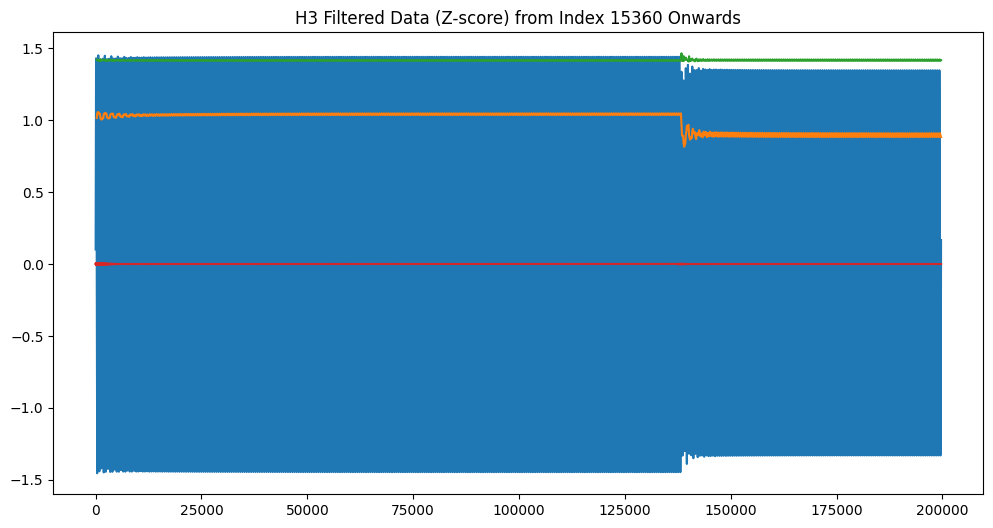

In [14]:
df = pd.DataFrame(df)
df_normalized = normalize_zscore(df.T)
w = [256]*len(df_normalized.columns)  # Assuming you want to apply the same window size for all columns
fs = [256*60]*len(df_normalized.columns)
f_system = 60
df_norm_inicio = df_normalized.iloc[15360:,:].reset_index(drop=True)
df_norm_inicio_ene = df_energy_rolling(df_norm_inicio, w)  # Assuming you want to apply the same window size for all columns
df_norm_inicio_crest = df_crest_factor_rolling(df_norm_inicio, w)  # Assuming you want to apply the same window size for all columns
df_norm_inicio_h3 = df_bandpass_filtering(df_norm_inicio, fs, f_center=3*f_system, bandwidth=10.0, order=4)
df_norm_inicio_h3_rms = df_envelope_rms(df_norm_inicio_h3)
df_h3_roc = df_temporal_derivative_simple(df_norm_inicio_h3_rms, w)


df_norm_inicio[28].plot(figsize=(12, 6), title="Normalized Data (Z-score) from Index 15360 Onwards")
df_norm_inicio_ene[28].plot(figsize=(12, 6), title="Energy of Normalized Data (Z-score) from Index 15360 Onwards")
df_norm_inicio_crest[28].plot(figsize=(12, 6), title="Crest Factor of Normalized Data (Z-score) from Index 15360 Onwards")
col_name = df_norm_inicio_h3.columns[27]
df_norm_inicio_h3[col_name].plot(
    figsize=(12, 6),
    title="H3 Filtered Data (Z-score) from Index 15360 Onwards"
)

<Axes: title={'center': 'Rate of Change of H3 Filtered Data (Z-score) from Index 15360 Onwards'}>

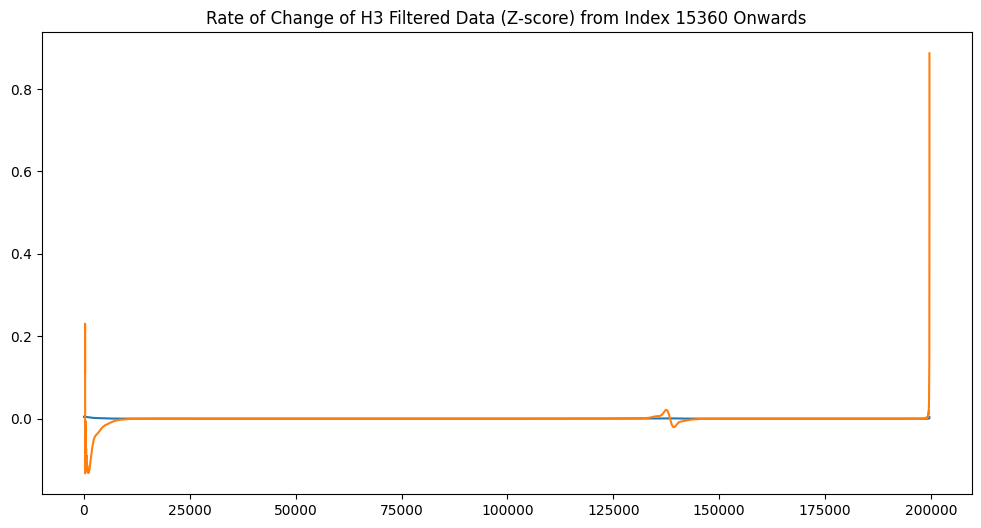

In [15]:
# df_norm_inicio[28].plot(
#     figsize=(12, 6),
#     title="Normalized Data (Z-score) from Index 15360 Onwards"
# )

df_norm_inicio_h3_rms.iloc[:, 28].plot(
    figsize=(12, 6),
    title="RMS of H3 Filtered Data (Z-score) from Index 15360 Onwards"
)
df_h3_roc.iloc[:, 28].plot(
    figsize=(12, 6),
    title="Rate of Change of H3 Filtered Data (Z-score) from Index 15360 Onwards"
)

Tamanho do Treino: 19 amostras
Tamanho do Teste: 10 amostras


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 34433, 16)      │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 17217, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 8609, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 4305, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 4305, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,769 (57.69 KB)

 Trainable params: 14,769 (57.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7368 - loss: 0.5573 - val_accuracy: 0.9000 - val_loss: 0.3112
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8421 - loss: 0.3410 - val_accuracy: 0.9000 - val_loss: 0.1185
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8421 - loss: 0.2395 - val_accuracy: 0.9000 - val_loss: 0.0854
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.1953 - val_accuracy: 0.9000 - val_loss: 0.0821
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.1597 - val_accuracy: 0.9000 - val_loss: 0.0786
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.1492 - val_accuracy: 0.9000 - val_loss: 0.0758
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8421 - loss: 0.1584 - val_accuracy: 0.9000 - val_loss: 0.0737
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8421 - loss: 0.1315 - val_accuracy: 0.9000 - v

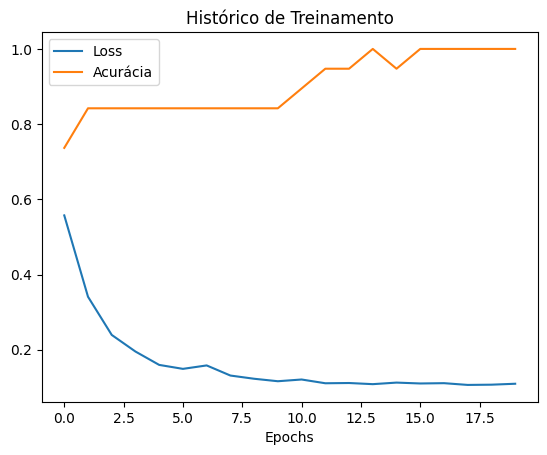

Acurácia final: 1.0000
Loss final: 0.1096
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

Resultados da Predição:
Sinal | Real | Predição | Probabilidade (0 a 1)
    1 | 1.0 |        1 | 1.0000
    2 | 1.0 |        1 | 1.0000
    3 | 1.0 |        1 | 0.9949
    4 | 1.0 |        1 | 1.0000
    5 | 1.0 |        1 | 0.9972
    6 | 1.0 |        1 | 1.0000
    7 | 1.0 |        1 | 1.0000
    8 | 1.0 |        1 | 1.0000
    9 | 1.0 |        1 | 1.0000
   10 | 1.0 |        1 | 0.9998
   11 | 1.0 |        1 | 1.0000
   12 | 1.0 |        1 | 1.0000
   13 | 1.0 |        1 | 1.0000
   14 | 1.0 |        1 | 1.0000
   15 | 1.0 |        1 | 1.0000
   16 | 1.0 |        1 | 1.0000
   17 | 1.0 |        1 | 1.0000
   18 | 1.0 |        1 | 1.0000
   19 | 1.0 |        1 | 1.0000
   20 | 1.0 |        1 | 1.0000
   21 | 1.0 |        1 | 1.0000
   22 | 1.0 |        1 | 1.0000
   23 | 1.0 |        1 | 1.0000
   24 | 1.0 |        1 | 1.0000
   25 | 1.0 |        1 | 1.0000
   26 | 0.0 |   

In [17]:
# 1. Transpor (T) para que os 6 sinais sejam as linhas, não as colunas
# x = df_norm_inicio_ene.dropna().values.T  # Shape passa de (N, 6) para (6, N)
# x = df_norm_inicio_crest.dropna().values.T
# x = df_norm_inicio_h3.dropna().values.T
x = df_h3_roc.dropna().values.T

# 2. Adicionar a dimensão do canal (necessário para Conv1D)
x = np.expand_dims(x, axis=-1)  # Shape fica (6, N, 1)

x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.33, 
    random_state=42, # Fixa a semente para resultados reproduzíveis
    stratify=y       # Garante que a classe '0' apareça no treino e no teste
)

print(f"Tamanho do Treino: {len(x_train)} amostras")
print(f"Tamanho do Teste: {len(x_test)} amostras")

# 4. Ajustar o Input do modelo para ler a dimensão de tempo correta
model = models.Sequential(
    [
        layers.Input(shape=(x_train.shape[1], x_train.shape[2])),  # (timesteps, channels)
        layers.Conv1D(filters=16, kernel_size=16, strides=2, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2, padding="same"),
        layers.Conv1D(filters=32, kernel_size=8, strides=2, padding="same", activation="relu"),
        layers.MaxPooling1D(pool_size=2, padding="same"),
        layers.Conv1D(filters=64, kernel_size=4, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

# 3. Compilação
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# 4. Treinamento de Teste
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test), # O Keras avalia esses dados ao fim de cada época
    epochs=20,
    batch_size=2,
    verbose=1,
)

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Acurácia')
plt.title('Histórico de Treinamento')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# 1. Imprimir as métricas finais do treinamento
print(f"Acurácia final: {history.history['accuracy'][-1]:.4f}")
print(f"Loss final: {history.history['loss'][-1]:.4f}")

print("-" * 30)

# 2. Gerar as predições usando os mesmos dados de entrada
predicoes = model.predict(x)

# 3. Imprimir os resultados comparando o Valor Real vs Valor Predito
print("\nResultados da Predição:")
print("Sinal | Real | Predição | Probabilidade (0 a 1)")
for i in range(len(y)):
    prob = predicoes[i][0]
    classe_predita = 1 if prob >= 0.5 else 0 # Limiar de 50%
    print(f"{i+1:5d} | {y[i]} | {classe_predita:8d} | {prob:.4f}")

results = np.column_stack((y, predicoes))

In [28]:
def classificar_sinal_janelado(sinal, modelo, tamanho_janela, passo):
    """
    Fatia um sinal longo em janelas e retorna a predição consolidada.
    """
    # 1. Extração das janelas (sliding window)
    janelas = [
        sinal[i : i + tamanho_janela] 
        for i in range(0, len(sinal) - tamanho_janela + 1, passo)
    ]
    
    # 2. Adequação de dimensionalidade para Conv1D: (num_janelas, tamanho_janela, canais)
    x_batch = np.array(janelas)
    if x_batch.ndim == 2:
        x_batch = np.expand_dims(x_batch, axis=-1)
        
    # 3. Predição em lote (processamento paralelo na GPU/CPU)
    probabilidades = modelo.predict(x_batch, verbose=0).flatten()
    
    # 4. Consolidação (Votação)
    classes_por_janela = (probabilidades >= 0.5).astype(int)
    
    # Se mais de 50% das janelas acusarem a classe 1, o sinal inteiro é 1
    predicao_final = 1 if np.mean(classes_por_janela) >= 0.5 else 0
    
    return predicao_final, probabilidades

# usa apenas um sinal (1D), e não a matriz 2D de todos os canais
sinal = x_test[0].squeeze()  # Remove a dimensão do canal para obter um vetor 1D

# o modelo foi treinado com sequências de tamanho x_train.shape[1]
seq_len = int(model.input_shape[1])

predicao_final, probabilidades = classificar_sinal_janelado(
    sinal,
    model,
    tamanho_janela=256,
    passo=128,
)

print(f"Predição final: {predicao_final}")
print(f"Probabilidades por janela: {probabilidades[:10]}")

Predição final: 1
Probabilidades por janela: [0.52492917 0.47928694 0.48196068 0.4778717  0.47813144 0.4786074
 0.4782717  0.5505472  0.69196117 0.794824  ]
